In [1]:
!pip install -U openai-whisper

In [2]:
!apt-get update
!apt-get install -y ffmpeg


Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (2,684 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (

In [3]:
!mkdir -p data/transcripts

In [4]:
import os

os.makedirs("data/transcripts", exist_ok=True)


In [5]:
import whisper
import re
import json

VIDEO_PATH = "/content/newton-s-first-law-of-motion-forces-and-motion-physics-infinity-learn-1080-publer.io.mp4"
OUTPUT_FILE = "data/transcripts/clean_whisper.json"

model = whisper.load_model("base")

result = model.transcribe(
    VIDEO_PATH,
    word_timestamps=True,
    verbose=False
)

def clean_text(text):
    fillers = r"\b(uh|umm|hmm|ahh|ohh+|aaa+|you know|okay so)\b"
    text = re.sub(fillers, "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text).strip()
    return text

output = []

for seg in result["segments"]:
    output.append({
        "start": round(seg["start"], 2),
        "end": round(seg["end"], 2),
        "text": clean_text(seg["text"])
    })

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2)

# NO further processing here


Detected language: English


100%|██████████| 15181/15181 [00:08<00:00, 1818.93frames/s]


In [6]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
import json
import nltk
import os

# Download tokenizer once
nltk.download("punkt")

INPUT_FILE = "data/transcripts/clean_whisper.json"
OUTPUT_FILE = "data/transcripts/sentence_timestamps.json"

# Load clean transcript
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    segments = json.load(f)

sentence_data = []

for seg in segments:
    sentences = nltk.sent_tokenize(seg["text"])

    # Avoid division by zero
    if len(sentences) == 0:
        continue

    seg_duration = seg["end"] - seg["start"]
    per_sentence_time = seg_duration / len(sentences)

    for i, sent in enumerate(sentences):
        sentence_data.append({
            "sentence": sent,
            "start": round(seg["start"] + i * per_sentence_time, 2),
            "end": round(seg["start"] + (i + 1) * per_sentence_time, 2)
        })

# Save output
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(sentence_data, f, indent=2)

print("✅ sentence_timestamps.json created successfully")


✅ sentence_timestamps.json created successfully


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [8]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW

# =============================
# LABEL NORMALIZATION (ONLY 4)
# =============================
LABEL_NORMALIZATION = {
    "factual": "Factual",
    "conceptual": "Conceptual",
    "procedural": "Procedural",
    "metacognitive": "Metacognitive"
}

LABEL_MAP = {
    "Factual": 0,
    "Conceptual": 1,
    "Procedural": 2,
    "Metacognitive": 3
}

# =============================
# LOAD & CLEAN DATASET
# =============================
df = pd.read_csv("physics_11_12_blooms_10k_dataset.csv")

# normalize labels
df["label"] = (
    df["label"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(LABEL_NORMALIZATION)
)

# safety check
if df["label"].isnull().any():
    print("❌ Unmapped labels found:")
    print(df[df["label"].isnull()]["label"].unique())
    raise ValueError("Fix label names in dataset")

# encode labels
df["label_id"] = df["label"].map(LABEL_MAP)

print("✅ Label distribution:")
print(df["label"].value_counts())

# =============================
# TOKENIZER
# =============================
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class KnowledgeDataset(Dataset):
    def __init__(self, sentences, labels):
        self.encodings = tokenizer(
            sentences.tolist(),
            truncation=True,
            padding=True,
            max_length=128
        )
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

dataset = KnowledgeDataset(df["sentence"], df["label_id"])
loader = DataLoader(dataset, batch_size=8, shuffle=True)

# =============================
# MODEL (4 LABELS ONLY)
# =============================
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4,
    problem_type="single_label_classification"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

# =============================
# TRAINING LOOP
# =============================
model.train()
for epoch in range(3):
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")

# =============================
# SAVE MODEL
# =============================
model.save_pretrained("bert_knowledge_model")
tokenizer.save_pretrained("bert_knowledge_model")

print("✅ BERT fine-tuning completed successfully (4-class model)")


✅ Label distribution:
label
Procedural       2500
Metacognitive    2500
Conceptual       2500
Factual          2500
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 | Loss: 54.6535
Epoch 2 | Loss: 0.6963
Epoch 3 | Loss: 0.2632


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ BERT fine-tuning completed successfully (4-class model)


In [9]:
import json
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# =============================
# HELPER: seconds → mm:ss
# =============================
def sec_to_mmss(sec):
    m = int(sec // 60)
    s = int(sec % 60)
    return f"{m}:{s:02d}"

# =============================
# LOAD MODEL
# =============================
MODEL_PATH = "bert_knowledge_model"

tokenizer = BertTokenizer.from_pretrained(MODEL_PATH)
model = BertForSequenceClassification.from_pretrained(MODEL_PATH)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# =============================
# LABEL MAP
# =============================
ID2LABEL = {
    0: "Factual",
    1: "Conceptual",
    2: "Procedural",
    3: "Metacognitive"
}

# =============================
# LOAD SENTENCE TIMESTAMPS
# =============================
with open("data/transcripts/sentence_timestamps.json", "r") as f:
    sentence_data = json.load(f)

sentence_level_output = []

# =============================
# INFERENCE (SENTENCE LEVEL)
# =============================
for item in sentence_data:
    inputs = tokenizer(
        item["sentence"],
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        pred_id = torch.argmax(outputs.logits, dim=1).item()

    sentence_level_output.append({
        "sentence": item["sentence"],
        "start": sec_to_mmss(item["start"]),
        "end": sec_to_mmss(item["end"]),
        "label": ID2LABEL[pred_id]
    })

# =============================
# SAVE FILE
# =============================
with open("sentence_level_transcript_with_labels.json", "w") as f:
    json.dump(sentence_level_output, f, indent=2)

print("✅ Sentence-level transcript with timestamps and labels created")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Sentence-level transcript with timestamps and labels created


In [10]:
import json

# =============================
# Helper: seconds → mm:ss
# =============================
def sec_to_mmss(sec):
    m = int(sec // 60)
    s = int(sec % 60)
    return f"{m}:{s:02d}"

# =============================
# Load sentence timestamps
# =============================
INPUT_FILE = "data/transcripts/sentence_timestamps.json"
OUTPUT_FILE = "timestamped_transcript.json"

with open(INPUT_FILE, "r") as f:
    sentence_data = json.load(f)

timestamped_transcript = []

for item in sentence_data:
    timestamped_transcript.append({
        "start": sec_to_mmss(item["start"]),
        "end": sec_to_mmss(item["end"]),
        "sentence": item["sentence"]
    })

# =============================
# Save output
# =============================
with open(OUTPUT_FILE, "w") as f:
    json.dump(timestamped_transcript, f, indent=2)

print("✅ Timestamped transcript file created successfully")

✅ Timestamped transcript file created successfully


In [11]:
import torch
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# 1. LOAD TRAINED MODEL
# ===============================
MODEL_PATH = "/content/bert_knowledge_model"

tokenizer = BertTokenizer.from_pretrained(MODEL_PATH)
model = BertForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("✅ BERT model loaded")

# ===============================
# 2. LOAD VALIDATION DATASET
# ===============================
df = pd.read_csv("/content/physics_knowledge_2000_dataset.csv")

# ===============================
# 3. LABEL NORMALIZATION
# ===============================
LABEL_NORMALIZATION = {
    "factual": "Factual",
    "conceptual": "Conceptual",
    "procedural": "Procedural",
    "metacognitive": "Metacognitive"
}

LABEL_MAP = {
    "Factual": 0,
    "Conceptual": 1,
    "Procedural": 2,
    "Metacognitive": 3
}

df["label"] = (
    df["label"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(LABEL_NORMALIZATION)
)

df["label_id"] = df["label"].map(LABEL_MAP)

print("\nValidation label distribution:")
print(df["label"].value_counts())

# ===============================
# 4. RUN PREDICTIONS
# ===============================
y_true = []
y_pred = []

for sentence, label in zip(df["text"], df["label_id"]):
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits
        pred = torch.argmax(logits, dim=1).item()

    y_true.append(label)
    y_pred.append(pred)

# ===============================
# 5. METRICS
# ===============================
print("\n================= RESULTS ================")
print("Accuracy:", accuracy_score(y_true, y_pred))

print(classification_report(
    y_true, y_pred,
    target_names=["Factual","Conceptual","Procedural","Metacognitive"]
))


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ BERT model loaded

Validation label distribution:
label
Metacognitive    555
Procedural       532
Factual          509
Conceptual       504
Name: count, dtype: int64

================= RESULTS ================
Accuracy: 0.7842857142857143
               precision    recall  f1-score   support

      Factual       0.61      0.98      0.75       509
   Conceptual       0.79      0.62      0.70       504
   Procedural       0.87      0.62      0.72       532
Metacognitive       1.00      0.91      0.95       555

     accuracy                           0.78      2100
    macro avg       0.82      0.78      0.78      2100
 weighted avg       0.82      0.78      0.78      2100



In [12]:
import json
import matplotlib.pyplot as plt
from collections import Counter


In [13]:
INPUT_FILE = "sentence_level_transcript_with_labels.json"

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)


In [14]:
labels = [item["label"] for item in data]
label_counts = Counter(labels)

total = sum(label_counts.values())

knowledge_levels = ["Conceptual", "Factual", "Metacognitive", "Procedural"]
percentages = [
    (label_counts.get(level, 0) / total) * 100
    for level in knowledge_levels
]


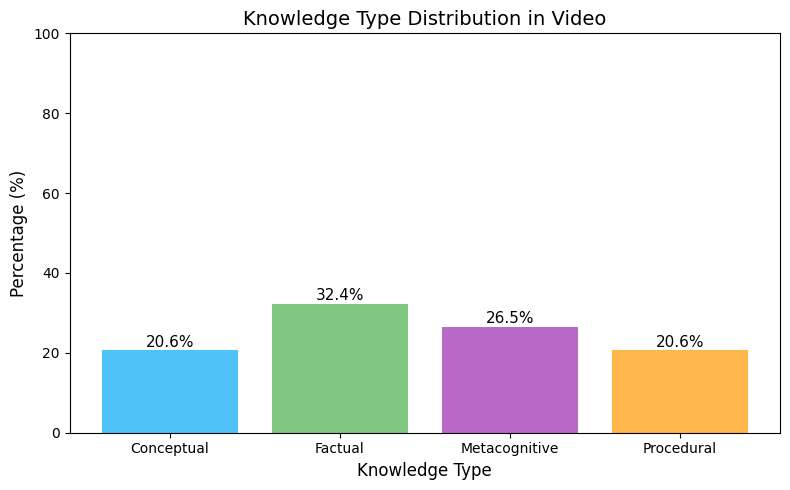

In [15]:
plt.figure(figsize=(8, 5))

# Color mapping for cognitive levels
colors = {
    "Conceptual": "#4FC3F7",      # Blue
    "Factual": "#81C784",         # Green
    "Metacognitive": "#BA68C8",   # Purple
    "Procedural": "#FFB74D"       # Orange
}

bar_colors = [colors[level] for level in knowledge_levels]

plt.bar(
    knowledge_levels,
    percentages,
    color=bar_colors
)

plt.title("Knowledge Type Distribution in Video", fontsize=14)
plt.xlabel("Knowledge Type", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.ylim(0, 100)

# Percentage labels on bars
for i, value in enumerate(percentages):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()


In [16]:
import json


In [17]:
def mmss_to_sec(time_str):
    m, s = time_str.split(":")
    return int(m) * 60 + int(s)


In [18]:
def sec_to_mmss(sec):
    m = int(sec // 60)
    s = int(sec % 60)
    return f"{m}:{s:02d}"


In [19]:
INPUT_FILE = "sentence_level_transcript_with_labels.json"
OUTPUT_FILE = "merged_label_segments.json"

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)


In [20]:
merged_output = []

current_label = None
current_start = None
current_end = None


In [21]:
for item in data:
    label = item["label"]
    start_sec = mmss_to_sec(item["start"])
    end_sec = mmss_to_sec(item["end"])

    # First entry
    if current_label is None:
        current_label = label
        current_start = start_sec
        current_end = end_sec
        continue

    # Same label → extend time
    if label == current_label:
        current_end = end_sec

    # Label changed → save previous segment
    else:
        merged_output.append({
            "start": sec_to_mmss(current_start),
            "end": sec_to_mmss(current_end),
            "label": current_label
        })

        current_label = label
        current_start = start_sec
        current_end = end_sec


In [22]:
if current_label is not None:
    merged_output.append({
        "start": sec_to_mmss(current_start),
        "end": sec_to_mmss(current_end),
        "label": current_label
    })


In [23]:
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(merged_output, f, indent=2)

print("✅ Merged cognitive-level segments saved successfully")


✅ Merged cognitive-level segments saved successfully


**LED Summarizer :**

In [24]:
!pip install -U transformers accelerate


In [25]:
import json
import torch
!pip install --upgrade huggingface_hub transformers
from transformers import LEDTokenizer, LEDForConditionalGeneration

In [26]:
INPUT_FILE = "data/transcripts/clean_whisper.json"

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    segments = json.load(f)

# Combine transcript into one long document
full_transcript = " ".join(seg["text"] for seg in segments)

print("Transcript length (chars):", len(full_transcript))


Transcript length (chars): 2019


In [27]:
MODEL_NAME = "allenai/led-base-16384"

tokenizer = LEDTokenizer.from_pretrained(MODEL_NAME)
model = LEDForConditionalGeneration.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()


Loading weights:   0%|          | 0/299 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

LEDForConditionalGeneration(
  (led): LEDModel(
    (shared): Embedding(50265, 768, padding_idx=1)
    (encoder): LEDEncoder(
      (embed_tokens): Embedding(50265, 768, padding_idx=1)
      (embed_positions): LEDLearnedPositionalEmbedding(16384, 768)
      (layers): ModuleList(
        (0-5): 6 x LEDEncoderLayer(
          (self_attn): LEDEncoderAttention(
            (longformer_self_attn): LEDEncoderSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (query_global): Linear(in_features=768, out_features=768, bias=True)
              (key_global): Linear(in_features=768, out_features=768, bias=True)
              (value_global): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): Linear(in_features=768, out_features=768, bias=True)
          )
     

In [28]:
inputs = tokenizer(
    full_transcript,
    return_tensors="pt",
    truncation=True,
    max_length=16384
)

input_ids = inputs["input_ids"].to(device)
attention_mask = inputs["attention_mask"].to(device)

# Global attention on first token (recommended by LED authors)
global_attention_mask = torch.zeros_like(attention_mask)
global_attention_mask[:, 0] = 1


In [29]:
with torch.no_grad():
    summary_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        global_attention_mask=global_attention_mask,

        max_length=15500,          # controls summary size
        min_length=150,          # prevents over-short summaries
        num_beams=4,             # beam search for quality
        length_penalty=2.0,      # discourages verbosity
        repetition_penalty=1.2,  # avoids repeated points
        no_repeat_ngram_size=3,
        early_stopping=True
    )


Input ids are automatically padded from 446 to 1024 to be a multiple of `config.attention_window`: 1024


In [30]:
summary_text = tokenizer.decode(
    summary_ids[0],
    skip_special_tokens=True
)

OUTPUT_FILE = "led_video_summary.txt"

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("✅ LED-based meaningful summary saved successfully")


✅ LED-based meaningful summary saved successfully


In [31]:
import os
os.makedirs("data/summaries", exist_ok=True)


In [32]:
OUTPUT_FILE = "data/summaries/led_meaningful_summary.txt"

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("✅ LED meaningful summary saved to:", OUTPUT_FILE)


✅ LED meaningful summary saved to: data/summaries/led_meaningful_summary.txt


**Save The Trained Fine tuned BERT modal**

In [33]:
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
MODEL_DRIVE_PATH = "/content/drive/MyDrive/bert_knowledge_model"


In [ ]:
model.save_pretrained(MODEL_DRIVE_PATH)
tokenizer.save_pretrained(MODEL_DRIVE_PATH)

print("✅ Fine-tuned BERT model saved to Google Drive")


✅ Fine-tuned BERT model saved to Google Drive
